<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Data_Science_for_Machine_Learning_Foundational_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")
%matplotlib inline

--- Section 1: SVD & Latent Features ---
Original Matrix Shape: (100, 4)
Singular values (ordered by variance explained): [2.56893967e+04 3.98910381e+02 1.38797248e+02 1.79304276e+00]


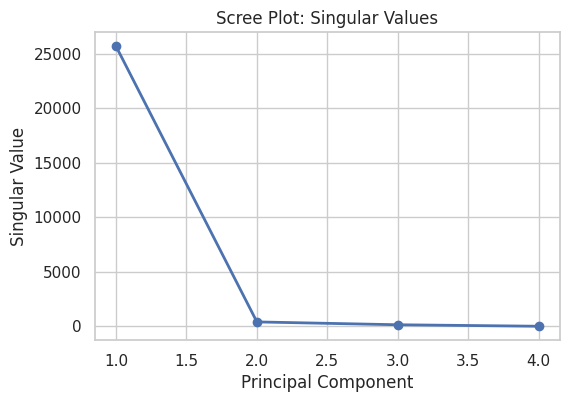

In [ ]:
print("--- Section 1: SVD & Latent Features ---")

# 1. Create a dummy dataset (100 houses, 4 highly correlated features)
# Features: SqFt, Rooms, Age, Noise_Level (added random noise)
base_feature = np.random.uniform(1000, 4000, (100, 1))
X_clean = np.hstack([
    base_feature,
    base_feature / 500 + np.random.normal(0, 0.2, (100, 1)), # Rooms
    40 - (base_feature / 100) + np.random.normal(0, 1, (100, 1)) # Age
])
# Add a purely noisy, redundant column
noise = np.random.normal(0, 50, (100, 1))
X = np.hstack([X_clean, noise])

# 2. Perform SVD
U, Sigma_diag, Vt = np.linalg.svd(X, full_matrices=False)

print(f"Original Matrix Shape: {X.shape}")
print(f"Singular values (ordered by variance explained): {Sigma_diag}")

# 3. Low-Rank Approximation (Keep top 2 latent components to denoise)
k = 2
Sigma_k = np.diag(Sigma_diag[:k])
U_k = U[:, :k]
Vt_k = Vt[:k, :]

X_denoised = np.dot(U_k, np.dot(Sigma_k, Vt_k))

# Plotting Singular Values
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(Sigma_diag) + 1), Sigma_diag, 'o-', linewidth=2)
plt.title("Scree Plot: Singular Values")
plt.xlabel("Principal Component")
plt.ylabel("Singular Value")
plt.show()

--- Section 2: EDA & Statistical Distributions ---

--- Descriptive Statistics ---
             SqFt     Rooms        Age          Price
mean  2410.542230  4.820868  15.931451  245408.379539
50%   2392.427364  4.719275  15.970654  243879.139192
std    892.468233  1.766828   8.988969  109040.518433

Skewness:
 SqFt     0.113381
Rooms    0.160819
Age     -0.048081
Price    0.130936
dtype: float64


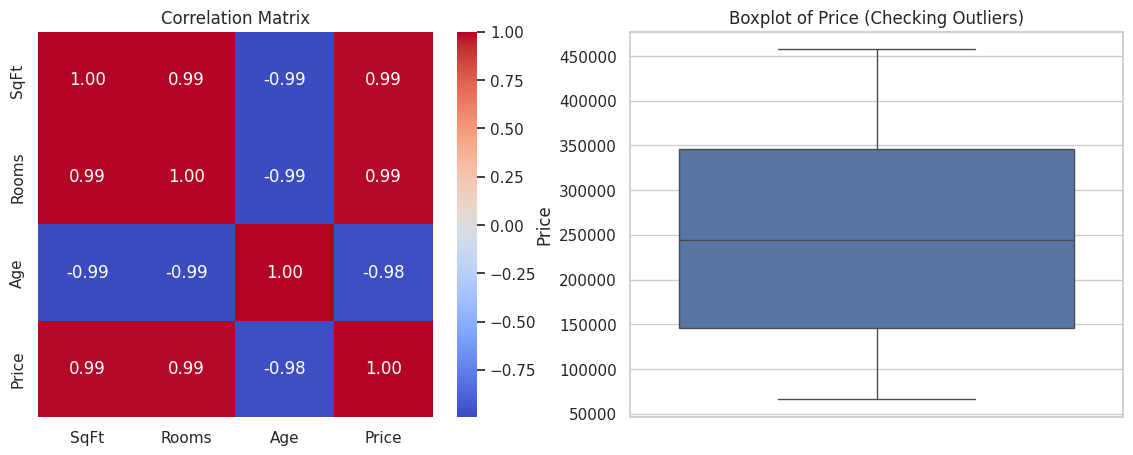

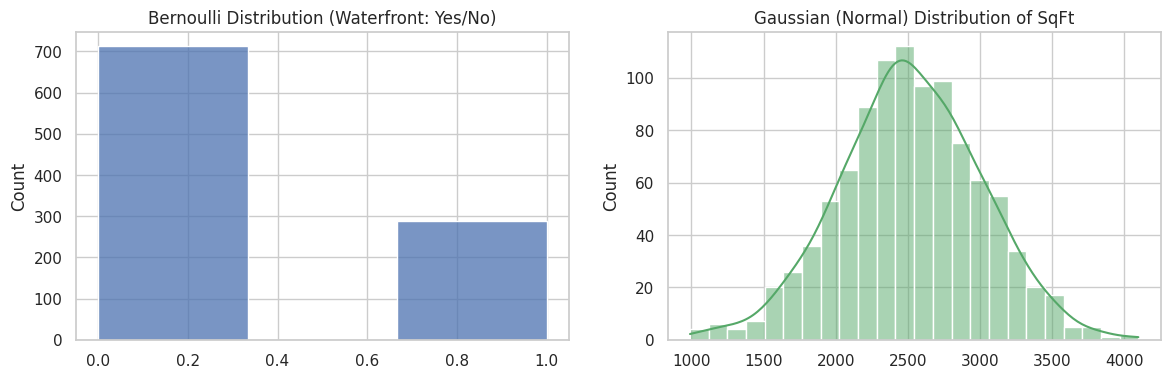

In [ ]:
print("--- Section 2: EDA & Statistical Distributions ---")

# Create a DataFrame for EDA
df = pd.DataFrame(X_clean, columns=['SqFt', 'Rooms', 'Age'])
df['Price'] = 100 * df['SqFt'] + 5000 * df['Rooms'] - 1200 * df['Age'] + np.random.normal(0, 15000, 100)

# 1. Descriptive Statistics
print("\n--- Descriptive Statistics ---")
print(df.describe().loc[['mean', '50%', 'std']]) # 50% is median
print("\nSkewness:\n", df.skew())

# 2. Visualization: Correlation Heatmap and Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation Matrix")

sns.boxplot(data=df, y='Price', ax=axes[1])
axes[1].set_title("Boxplot of Price (Checking Outliers)")
plt.show()

# 3. Theoretical Distributions: Bernoulli and Gaussian
bernoulli_data = np.random.binomial(n=1, p=0.3, size=1000) # p=0.3 for Waterfront property
gaussian_data = np.random.normal(loc=2500, scale=500, size=1000) # SqFt distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(bernoulli_data, kde=False, ax=axes[0], bins=3)
axes[0].set_title("Bernoulli Distribution (Waterfront: Yes/No)")

sns.histplot(gaussian_data, kde=True, ax=axes[1], color='g')
axes[1].set_title("Gaussian (Normal) Distribution of SqFt")
plt.show()

--- Section 3: Bayesian Framework ---
Prior Belief: Weight ~ N(0.0, 1.0)
Posterior Distribution after observing data: Weight ~ N(0.9869, 0.0020)


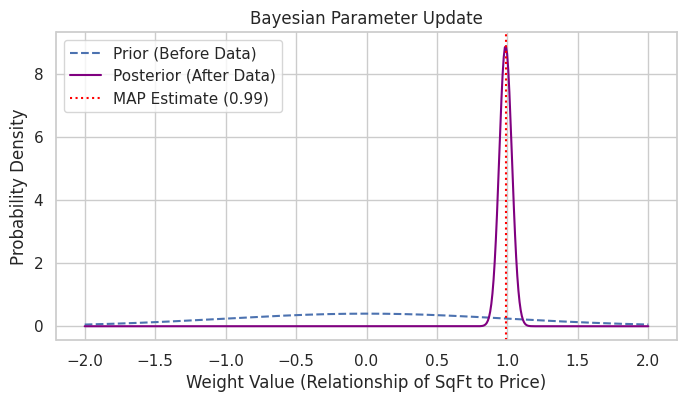

In [ ]:
print("--- Section 3: Bayesian Framework ---")

# Normalized feature for simpler visualization
x_train = (df['SqFt'].values - df['SqFt'].mean()) / df['SqFt'].std()
y_train = (df['Price'].values - df['Price'].mean()) / df['Price'].std()

# Prior distribution parameters: Mean=0, Variance=1
prior_mean = 0.0
prior_var = 1.0

# Noise variance in data (assumed known for this example)
noise_var = 0.2

# Closed-form Bayesian Update for a single weight parameter
# Posterior Variance: 1 / (1/PriorVar + Sum(x^2)/NoiseVar)
post_var = 1.0 / ((1.0 / prior_var) + np.sum(x_train**2) / noise_var)
# Posterior Mean: PostVar * (PriorMean/PriorVar + Sum(x*y)/NoiseVar)
post_mean = post_var * ((prior_mean / prior_var) + np.sum(x_train * y_train) / noise_var)

print(f"Prior Belief: Weight ~ N({prior_mean}, {prior_var})")
print(f"Posterior Distribution after observing data: Weight ~ N({post_mean:.4f}, {post_var:.4f})")

# Visualize Prior vs Posterior
weights = np.linspace(-2, 2, 500)
prior_pdf = (1/np.sqrt(2*np.pi*prior_var)) * np.exp(-(weights - prior_mean)**2 / (2*prior_var))
post_pdf = (1/np.sqrt(2*np.pi*post_var)) * np.exp(-(weights - post_mean)**2 / (2*post_var))

plt.figure(figsize=(8, 4))
plt.plot(weights, prior_pdf, label='Prior (Before Data)', linestyle='--')
plt.plot(weights, post_pdf, label='Posterior (After Data)', color='purple')
plt.axvline(post_mean, color='red', linestyle=':', label=f'MAP Estimate ({post_mean:.2f})')
plt.title("Bayesian Parameter Update")
plt.xlabel("Weight Value (Relationship of SqFt to Price)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

--- Section 4: Bias-Variance Tradeoff & Regularization ---


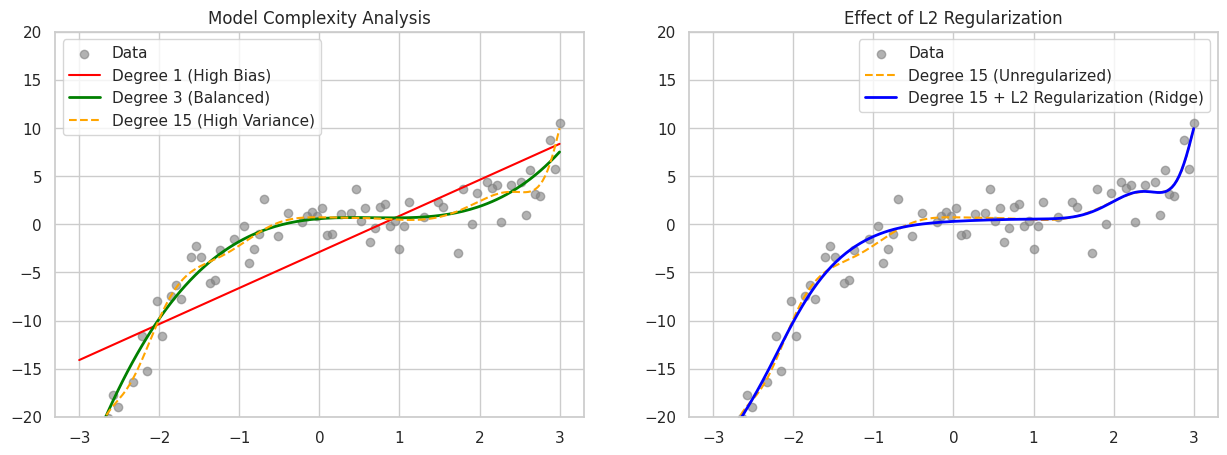

In [ ]:
print("--- Section 4: Bias-Variance Tradeoff & Regularization ---")

# Generate synthetic non-linear data
X_nl = np.linspace(-3, 3, 100).reshape(-1, 1)
y_nl = 0.5 * X_nl**3 - X_nl**2 + X_nl + np.random.normal(0, 2, size=(100, 1))

X_train, X_test, y_train, y_test = train_test_split(X_nl, y_nl, test_size=0.3, random_state=42)

# Helper function to generate features
def fit_poly(degree, reg_model=None):
    poly = PolynomialFeatures(degree=degree)
    X_poly_tr = poly.fit_transform(X_train)
    X_poly_te = poly.transform(X_test)

    model = reg_model if reg_model is not None else LinearRegression()
    model.fit(X_poly_tr, y_train)

    # Generate line plot points
    X_line = np.linspace(-3, 3, 200).reshape(-1, 1)
    y_line = model.predict(poly.transform(X_line))
    return X_line, y_line, model

# Fit models representing High Bias, Balanced, and High Variance
x_l1, y_l1, _ = fit_poly(degree=1) # Underfit
x_l3, y_l3, _ = fit_poly(degree=3) # Balanced
x_l15, y_l15, m_15 = fit_poly(degree=15) # Overfit
x_r15, y_r15, _ = fit_poly(degree=15, reg_model=Ridge(alpha=10)) # Regularized Overfit

# Plotting comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(X_train, y_train, color='gray', alpha=0.6, label='Data')
axes[0].plot(x_l1, y_l1, label='Degree 1 (High Bias)', color='red')
axes[0].plot(x_l3, y_l3, label='Degree 3 (Balanced)', color='green', linewidth=2)
axes[0].plot(x_l15, y_l15, label='Degree 15 (High Variance)', color='orange', linestyle='--')
axes[0].set_ylim(-20, 20)
axes[0].set_title("Model Complexity Analysis")
axes[0].legend()

# Plotting the effect of Regularization
axes[1].scatter(X_train, y_train, color='gray', alpha=0.6, label='Data')
axes[1].plot(x_l15, y_l15, label='Degree 15 (Unregularized)', color='orange', linestyle='--')
axes[1].plot(x_r15, y_r15, label='Degree 15 + L2 Regularization (Ridge)', color='blue', linewidth=2)
axes[1].set_ylim(-20, 20)
axes[1].set_title("Effect of L2 Regularization")
axes[1].legend()
plt.show()

--- Section 5: Uncertainty Quantification ---


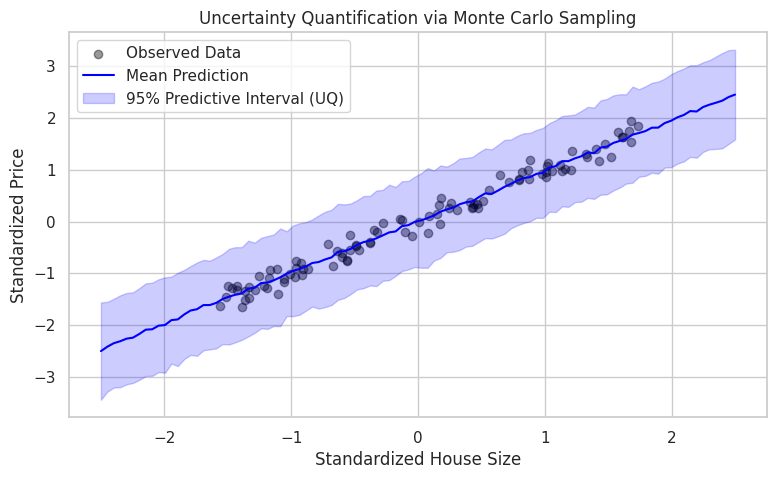

In [ ]:
print("--- Section 5: Uncertainty Quantification ---")

# Re-evaluate x_train and y_train from Section 3 to ensure correct scope and size
x_train = (df['SqFt'].values - df['SqFt'].mean()) / df['SqFt'].std()
y_train = (df['Price'].values - df['Price'].mean()) / df['Price'].std()

# Assume an ensemble of models or parameters drawn from our Section 3 posterior
# We simulate 500 different lines using weight distributions to evaluate an unseen property
X_new_house = np.linspace(-2.5, 2.5, 100).reshape(-1, 1)

# Generate a distribution of predictions via Monte Carlo draws of coefficients
n_simulations = 500
mc_predictions = []

for _ in range(n_simulations):
    # Draw sample weights based on our computed posterior stats
    sampled_weight = np.random.normal(loc=post_mean, scale=np.sqrt(post_var))
    # Generate prediction adding intrinsic observation error
    y_pred = sampled_weight * X_new_house.flatten() + np.random.normal(0, np.sqrt(noise_var), size=100)
    mc_predictions.append(y_pred)

mc_predictions = np.array(mc_predictions) # Shape: (500, 100)

# Extract mean and standard deviations of predictions for each sample point
mean_prediction = np.mean(mc_predictions, axis=0)
std_prediction = np.std(mc_predictions, axis=0)

# Plotting Uncertainty Bounds
plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train.flatten(), color='black', alpha=0.4, label='Observed Data')
plt.plot(X_new_house, mean_prediction, color='blue', label='Mean Prediction')
plt.fill_between(X_new_house.flatten(),
                 mean_prediction - 1.96 * std_prediction,
                 mean_prediction + 1.96 * std_prediction,
                 color='blue', alpha=0.2, label='95% Predictive Interval (UQ)')
plt.title("Uncertainty Quantification via Monte Carlo Sampling")
plt.xlabel("Standardized House Size")
plt.ylabel("Standardized Price")
plt.legend(loc="upper left")
plt.show()